- 線形attention
- すべてのパラメータを学習するが正則化をつける
- Nを固定したまま異なるMの効果を検証

In [ ]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

# ===== 実験設定（元ノートの値を維持） =====
D = 10
N = 80
ETA_GD = 0.1
BATCH_SIZE = 300
ADAM_LR = 1e-3
PARAM_L2_LAMBDA = 0.1
ITERATIONS = 1500
EVAL_K_LIST = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10]
SEED = 420

# 複数 M を比較
M_LIST = [500, 1000, 5000, 20000, 50000]

# 固定条件
W0_INIT_MODE = "random"
TRAINING_MODE = "no_cot"

DE = 2 * D + 2

np.random.seed(SEED)
torch.manual_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(
    f"device={device}, d={D}, n={N}, B={BATCH_SIZE}, iters={ITERATIONS}, "
    f"w0={W0_INIT_MODE}, mode={TRAINING_MODE}, l2={PARAM_L2_LAMBDA}, M_LIST={M_LIST}"
)


device=cpu, d=20, n=40, B=300, iters=1500, w0=random, mode=no_cot, l2=0.1, M_LIST=[500, 1000, 5000, 20000, 50000]


In [18]:
def sample_task_batch(batch_size, d=D, n=N, device=device):
    X = torch.randn(batch_size, d, n, device=device)
    w_star = torch.randn(batch_size, d, device=device)
    y = torch.einsum("bd,bdn->bn", w_star, X)
    return X, y, w_star


def build_fixed_train_dataset(M):
    X, y, w_star = sample_task_batch(M)
    return {"X": X, "y": y, "w_star": w_star, "M": M}


def sample_train_minibatch(train_data, batch_size=BATCH_SIZE):
    # 復元抽出（同じデータが複数回選ばれうる）
    idx = torch.randint(0, train_data["M"], (batch_size,), device=device)
    return train_data["X"][idx], train_data["y"][idx], train_data["w_star"][idx]


def sample_w0_random(X, d=D, device=device):
    return torch.randn(X.shape[0], d, device=device)


def build_Z(X, y, w_prefix):
    B, d, n = X.shape
    i = len(w_prefix) - 1
    L = n + i + 1
    Z = torch.zeros(B, DE, L, device=X.device)
    Z[:, :d, :n] = X
    Z[:, d, :n] = y
    for t, w_t in enumerate(w_prefix):
        Z[:, d + 1 : d + 1 + d, n + t] = w_t
    Z[:, -1, :] = 1.0
    return Z


def f_lsa_last(Z, V, W, n=N):
    z_last = Z[:, :, -1]
    Wz = torch.einsum("ij,bj->bi", W, z_last)
    scores = torch.einsum("bjl,bj->bl", Z, Wz) / n
    weighted = torch.einsum("bjl,bl->bj", Z, scores)
    out_last = z_last + torch.einsum("ij,bj->bi", V, weighted)
    return out_last


def no_cot_train_loss(V, W, X, y, w_star):
    w0 = sample_w0_random(X, D, X.device)
    Z0 = build_Z(X, y, [w0])
    pred = f_lsa_last(Z0, V, W)
    target = torch.zeros_like(pred)
    target[:, D + 1 : D + 1 + D] = w_star
    target[:, -1] = 1.0
    return 0.5 * ((pred - target) ** 2).sum(dim=1).mean()


def eval_loss(V, W, k_eval, batch_size=2048):
    # 評価は新規タスク
    X, y, w_star = sample_task_batch(batch_size)
    with torch.no_grad():
        w0 = sample_w0_random(X, D, device)
        w_prefix = [w0]
        for _ in range(k_eval):
            Z = build_Z(X, y, w_prefix)
            pred = f_lsa_last(Z, V, W)
            w_hat = pred[:, D + 1 : D + 1 + D]
            w_prefix.append(w_hat)
        Z_final = build_Z(X, y, w_prefix)
        pred_final = f_lsa_last(Z_final, V, W)
        target = torch.zeros_like(pred_final)
        target[:, D + 1 : D + 1 + D] = w_star
        target[:, -1] = 1.0
        loss = 0.5 * ((pred_final - target) ** 2).sum(dim=1).mean().item()
    return loss


def parameter_l2_penalty(V, W):
    return V.pow(2).sum() + W.pow(2).sum()


def train_model_no_cot_finite(train_data, iterations=ITERATIONS, log_every=20):
    V = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    W = nn.Parameter(0.01 * torch.randn(DE, DE, device=device))
    opt = torch.optim.Adam([V, W], lr=ADAM_LR)

    eval_curve = []
    for t in range(iterations):
        X, y, w_star = sample_train_minibatch(train_data, BATCH_SIZE)
        data_loss = no_cot_train_loss(V, W, X, y, w_star)
        reg_loss = PARAM_L2_LAMBDA * parameter_l2_penalty(V, W)
        loss = data_loss + reg_loss

        opt.zero_grad(set_to_none=True)
        loss.backward()
        opt.step()

        if t % log_every == 0:
            eval_curve.append(eval_loss(V, W, k_eval=0))

    return V.detach(), W.detach(), np.array(eval_curve)


In [19]:
assert TRAINING_MODE == "no_cot"
assert W0_INIT_MODE == "random"

results_by_M = {}

for M in M_LIST:
    print(f"\n=== training with fixed M={M} ===")
    train_data = build_fixed_train_dataset(M)
    V_tr, W_tr, train_curve = train_model_no_cot_finite(train_data, iterations=ITERATIONS)

    final_eval = {}
    for k_eval in EVAL_K_LIST:
        final_eval[k_eval] = eval_loss(V_tr, W_tr, k_eval=k_eval)
    results_by_M[M] = {
        "final_eval": final_eval,
        "train_curve": train_curve,
    }

    for k_eval in EVAL_K_LIST:
        print(f"M={M:>6}, k_eval={k_eval:>2}: {final_eval[k_eval]:.6f}")



=== training with fixed M=500 ===
M=   500, k_eval= 0: 5.903874
M=   500, k_eval= 1: 2.843528
M=   500, k_eval= 2: 1.995958
M=   500, k_eval= 3: 2.052526
M=   500, k_eval= 4: 2.376907
M=   500, k_eval= 5: 2.950856
M=   500, k_eval= 6: 3.451796
M=   500, k_eval= 7: 13.064230
M=   500, k_eval= 8: 202566.171875
M=   500, k_eval= 9: 2107613921969475722197669511168.000000
M=   500, k_eval=10: 61549524.000000

=== training with fixed M=1000 ===
M=  1000, k_eval= 0: 5.748183
M=  1000, k_eval= 1: 2.843071
M=  1000, k_eval= 2: 1.960808
M=  1000, k_eval= 3: 1.956081
M=  1000, k_eval= 4: 2.344355
M=  1000, k_eval= 5: 2.874341
M=  1000, k_eval= 6: 3.406846
M=  1000, k_eval= 7: 3.779531
M=  1000, k_eval= 8: 759869056.000000
M=  1000, k_eval= 9: 4.642454
M=  1000, k_eval=10: 257.932770

=== training with fixed M=5000 ===
M=  5000, k_eval= 0: 5.748702
M=  5000, k_eval= 1: 2.784558
M=  5000, k_eval= 2: 1.838032
M=  5000, k_eval= 3: 1.854528
M=  5000, k_eval= 4: 2.182293
M=  5000, k_eval= 5: 2.719125


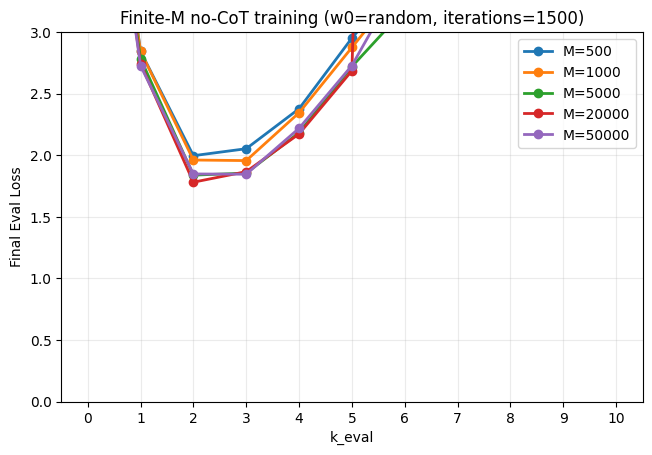

In [20]:
# M ごとの結果を重ね描き
plt.figure(figsize=(7.5, 4.8))
for M in M_LIST:
    ks = np.array(sorted(results_by_M[M]["final_eval"].keys()))
    vals = np.array([results_by_M[M]["final_eval"][k] for k in ks])
    plt.plot(ks, vals, marker="o", linewidth=2, label=f"M={M}")

plt.xlabel("k_eval")
plt.ylabel("Final Eval Loss")
plt.title(f"Finite-M no-CoT training (w0=random, iterations={ITERATIONS})")
plt.xticks(EVAL_K_LIST)
plt.ylim(0, 3.0)
plt.grid(alpha=0.25)
plt.legend()
plt.show()
